In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

# --- GERANDO A BASE SINTÉTICA DA STREAMFLIX ---
np.random.seed(10)
n_usuarios = 800

idades = np.random.randint(14, 75, n_usuarios)
cartoes = [f"1234-5678-9012-{1000+i}" for i in range(n_usuarios)]
planos = np.random.choice(['Basico', 'Premium', 'Familia'], n_usuarios)
interfaces = np.random.choice(['Antiga', 'Nova'], n_usuarios)

# Simulando tempo de tela diferente para o Teste A/B
tempo_antiga = np.random.normal(45, 15, 400)
tempo_nova = np.random.normal(58, 15, 400)
tempo_assistido = np.concatenate([tempo_antiga, tempo_nova])
np.random.shuffle(tempo_assistido)

# Simulando gasto com base no tempo assistido (relação linear)
mensalidade = (tempo_assistido * 0.6) + 15 + np.random.normal(loc=0, scale=8, size=800)
# Criando outliers (fraudes ou erros de sistema)
mensalidade[12] = 1200
mensalidade[405] = 950

df = pd.DataFrame({
    'Idade': idades,
    'Cartao_Credito': cartoes,
    'Plano': planos,
    'Interface_App': interfaces,
    'Tempo_Assistido_Min': np.abs(tempo_assistido),
    'Mensalidade_Paga_R$': np.abs(mensalidade)
})

print("Base da StreamFlix gerada com sucesso!")
display(df.head())
df_seguro = df.drop(columns='Cartao_Credito')
df_seguro.head()

Base da StreamFlix gerada com sucesso!


,Idade,Cartao_Credito,Plano,Interface_App,Tempo_Assistido_Min,Mensalidade_Paga_R$
0,23,1234-5678-9012-1000,Familia,Nova,56.336506,51.419206
1,50,1234-5678-9012-1001,Familia,Antiga,63.040866,51.298216
2,29,1234-5678-9012-1002,Premium,Antiga,72.236008,69.571936
3,14,1234-5678-9012-1003,Familia,Antiga,55.933786,63.280733
4,63,1234-5678-9012-1004,Basico,Nova,33.504019,37.293112


,Idade,Plano,Interface_App,Tempo_Assistido_Min,Mensalidade_Paga_R$
0,23,Familia,Nova,56.336506,51.419206
1,50,Familia,Antiga,63.040866,51.298216
2,29,Premium,Antiga,72.236008,69.571936
3,14,Familia,Antiga,55.933786,63.280733
4,63,Basico,Nova,33.504019,37.293112


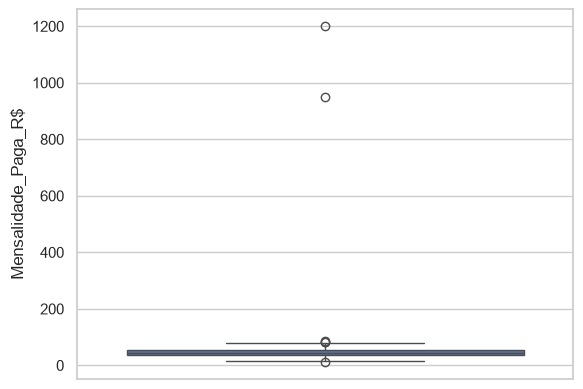

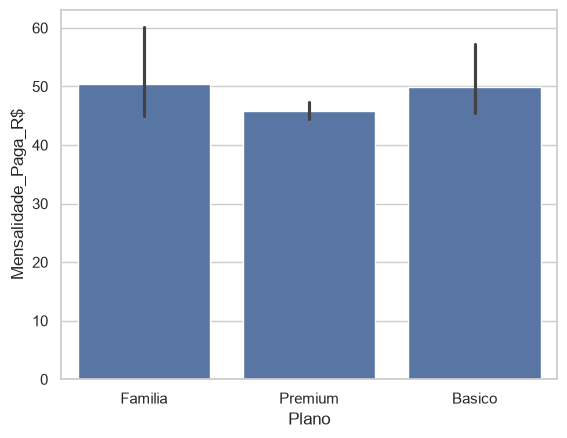

<Axes: title={'center': 'Correlação '}>

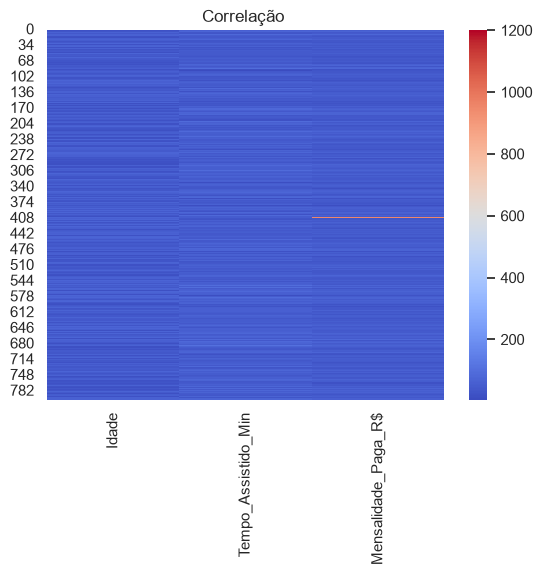

In [ ]:
# MISSÃO 1: LGPD e Privacidade
# 1. Remova a coluna 'Cartao_Credito' que expõe dados sensíveis financeiros.
# 2. Salve em 'df_seguro' e exiba as primeiras linhas.
df_seguro = df.drop(columns='Cartao_Credito')
df_seguro.head()

# MISSÃO 2: Exploração Visual e Outliers
# 1. Faça um sns.boxplot da coluna 'Mensalidade_Paga_R$' para identificar visualmente os outliers.

sns.boxplot(y=df['Mensalidade_Paga_R$'])
plt.show()

# 2. Faça um sns.barplot mostrando a 'Mensalidade_Paga_R$' (y) por 'Plano' (x).
sns.barplot(y=df['Mensalidade_Paga_R$'],x=df['Plano'])
plt.show()

# SEU CÓDIGO AQUI:


# MISSÃO 3: O Poder da Correlação (Matriz e Gráficos)
# 1. Crie um sns.scatterplot cruzando 'Tempo_Assistido_Min' (x) e 'Mensalidade_Paga_R$' (y). 
x_curva = df['Tempo_Assistido_Min']
y_curva = df['Mensalidade_Paga_R$']
df_curva = pd.DataFrame({'X': x_curva, 'Y': y_curva})

pearson = df_curva['X'].corr(df_curva['Y'], method='pearson')

# 2. Desenhe o Scatterplot dessas duas colunas.

sns.scatterplot(x=x_curva, y=y_curva,  color='blue').set_title('Correlação ')
#    Olhando para os pontos, eles andam juntos?
#Sim , quando tempo sobe a mensalidade tb
# 2. Isole apenas as colunas numéricas (Idade, Tempo, Mensalidade) e calcule a matriz de correlação usando df.corr().
df_numerico = df.drop(columns=['Cartao_Credito', 'Plano', 'Interface_App'])

# 3. Plote essa matriz num sns.heatmap(..., annot=True, cmap='coolwarm').
sns.heatmap(df_numerico, annot=True, cmap='coolwarm')

# SEU CÓDIGO AQUI:


# MISSÃO 4: Teste A/B da Nova Interface
# A equipe de Produto lançou a interface 'Nova'. Ela realmente faz o usuário assistir mais tempo que a 'Antiga'?
# 1. Isole o Tempo_Assistido_Min da interface 'Antiga' (tempo_A).
# 2. Isole o Tempo_Assistido_Min da interface 'Nova' (tempo_B).
# 3. Use stats.ttest_ind e imprima o p-valor. Se for < 0.05, a interface nova venceu.

# SEU CÓDIGO AQUI:


# MISSÃO 5: Motor de Previsão de Faturamento (Regressão Linear)
# IMPORTANTE: Filtre os outliers (Mensalidade < 800) antes de treinar!
# 1. Separe o X ('Tempo_Assistido_Min') em 2D, e o y ('Mensalidade_Paga_R$') em 1D.
# 2. Treine o modelo LinearRegression.
# 3. Imprima o R2 Score e o RMSE.
# 4. PREVISÃO: Se um usuário passar exatos 120 minutos assistindo, quanto o modelo prevê que ele vai pagar? 

# SEU CÓDIGO AQUI: